# Data Assimilaiton on a reduced order model

In [1]:
import numpy as np
from romda.utils import  load_cylinder_dataset

X_true, X_noisy, simulation_dir = load_cylinder_dataset(noise_type='gauss', 
                                                        noise_level=0.02, 
                                                        smoothing=0.01,
                                                        visualize=True,
                                                        )

Loading.../Users/anovoa/codes/real-time-bias-aware-DA/results/tutorials/wakes//data_noise0.02gauss_smoothing0.01/00_data.mat


In [2]:

# # ## 5. Create Observations from test flowfields
# # Project the true and noisy test flow fields onto the trained POD modes,
# # then wrap them in an `Observations` object for downstream data assimilation.

# # %%
# from observations import Observations

# Nt_test = X_test.shape[1]
# t_test  = np.arange(Nt_test) * dt

# # Flatten test flow fields onto fluid points using the same NaN mask as training
# # (subtract_mean=False because project_data_onto_Psi subtracts the training mean)
# Q_test_true,  _, _ = prepare_data([*X_test_true], subtract_mean=False)
# Q_test_noisy, _, _ = prepare_data([*X_test],      subtract_mean=False)

# # Project onto POD modes → temporal coefficients (Nt_test, N_modes)
# Phi_test_true  = case_ESN.project_data_onto_Psi(Q_test_true,  remove_mean=True)
# Phi_test_noisy = case_ESN.project_data_onto_Psi(Q_test_noisy, remove_mean=True)

# obs = Observations(
#     model=None,
#     y_true=Phi_test_true,
#     y_raw=Phi_test_noisy,
#     t_true=t_test,
#     t_start=t_test[0],
#     t_stop=t_test[-1],
#     Nt_obs=20,
# )

# print(f'y_obs shape : {obs.y_obs.shape}  ({len(obs.t_obs)} observation times)')


In [3]:
print(f'Dimension of the data:  {X_true.shape}= (N_samples, Nx, Ny, N_vars). \nTotal d.o.f. = {np.prod(X_true.shape[1:])}.')

Dimension of the data:  (800, 513, 129, 2)= (N_samples, Nx, Ny, N_vars). 
Total d.o.f. = 132354.



# Part I. Building the POD-ESN model


In [4]:
### Separate the dataset into data to train the POD-ESN and data to test the POD-ESN-EnKF

N_train = 40
N_val = 20

X_train, X_train_true = [yy[:N_train+N_val].transpose(-1, 0, 1, 2) for yy in [X_noisy, X_true]]
X_filter, X_filter_true = [yy[N_train+N_val:].transpose(-1, 0, 1, 2) for yy in [X_noisy, X_true]]

dt = 0.01
t_val = N_val * dt 
t_train = N_train * dt 



In [5]:
X_train.shape

(2, 60, 513, 129)

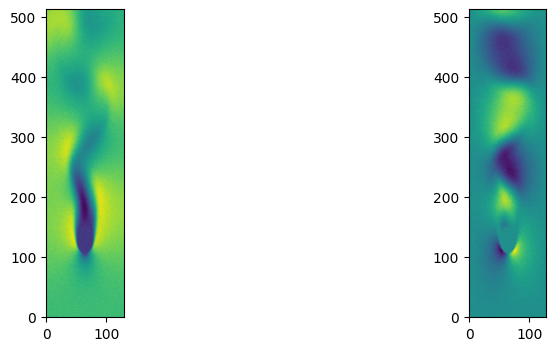

In [6]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].imshow(X_train[0, 0, :], cmap='viridis', origin='lower')
axs[1].imshow(X_train[1, 0, :], cmap='viridis', origin='lower')



Training ESN model...


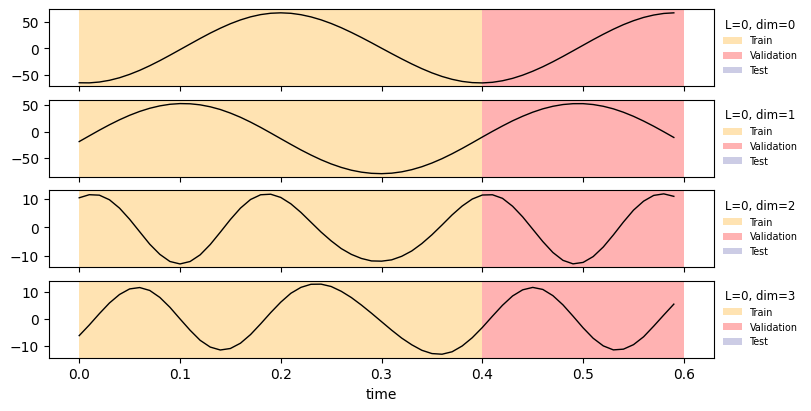

Modifying domain = [0, 12, -2.5, 2.5] -> [0, 12, -2.5, 2.5] at training.
Modifying N_modes = 4 -> 4 at training.

 ----------------- HYPERPARAMETER SEARCH ------------------
 5x5 grid and 1 points with Bayesian Optimization
		 rho	 sigma_in	 tikh	 MSE val 
1	 2.000e-01	 1.000e-02	 1.000e-06	 -1.6933
2	 2.000e-01	 1.000e-01	 1.000e-06	 -1.7091
3	 2.000e-01	 1.000e+00	 1.000e-06	 -2.1405
4	 2.000e-01	 1.000e+01	 1.000e-06	 -1.4588
5	 2.000e-01	 1.000e+02	 1.000e-06	 -0.1229
6	 3.750e-01	 1.000e-02	 1.000e-06	 -1.3277
7	 3.750e-01	 1.000e-01	 1.000e-06	 -1.6830
8	 3.750e-01	 1.000e+00	 1.000e-06	 -1.6021
9	 3.750e-01	 1.000e+01	 1.000e-06	 -1.2930
10	 3.750e-01	 1.000e+02	 1.000e-09	 -0.0720
11	 5.500e-01	 1.000e-02	 1.000e-06	 -1.3119
12	 5.500e-01	 1.000e-01	 1.000e-06	 -1.4586
13	 5.500e-01	 1.000e+00	 1.000e-06	 -1.2811
14	 5.500e-01	 1.000e+01	 1.000e-06	 -1.2894
15	 5.500e-01	 1.000e+02	 1.000e-06	 0.2734
16	 7.250e-01	 1.000e-02	 1.000e-06	 -1.2048
17	 7.250e-01	 1.000e-01	 1.000e-

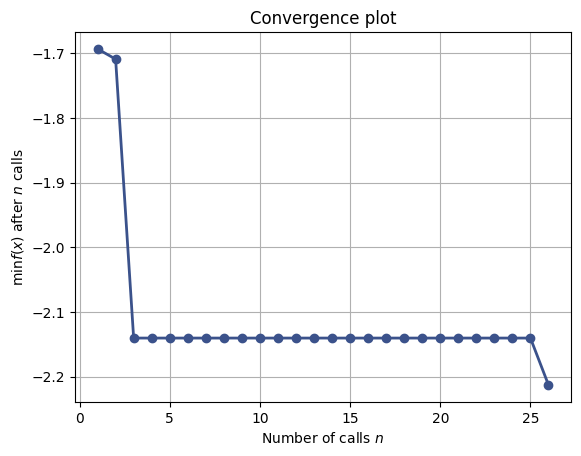

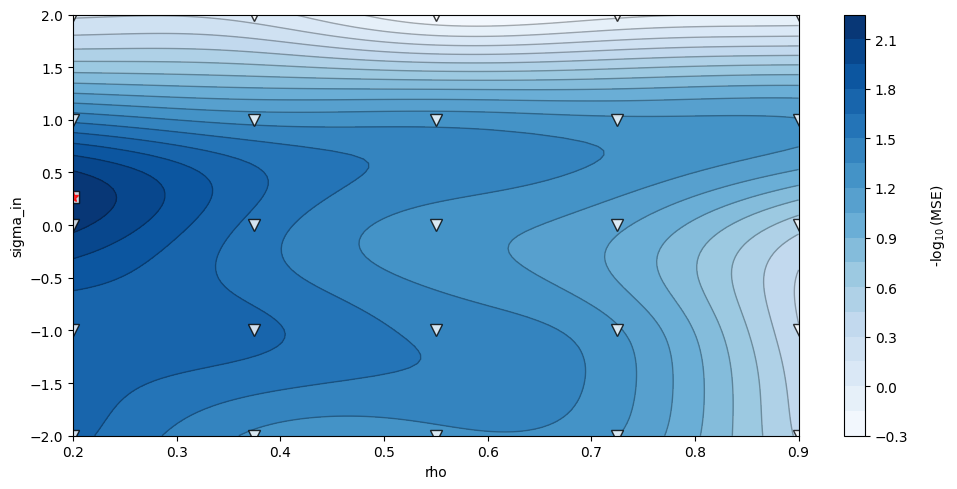

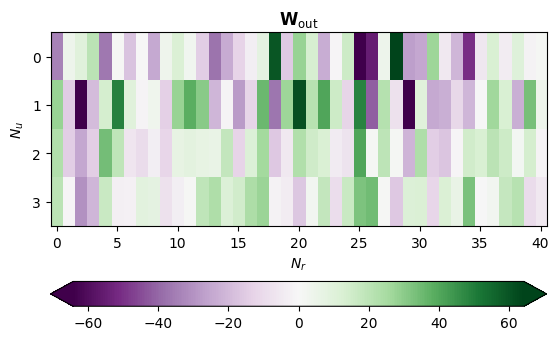

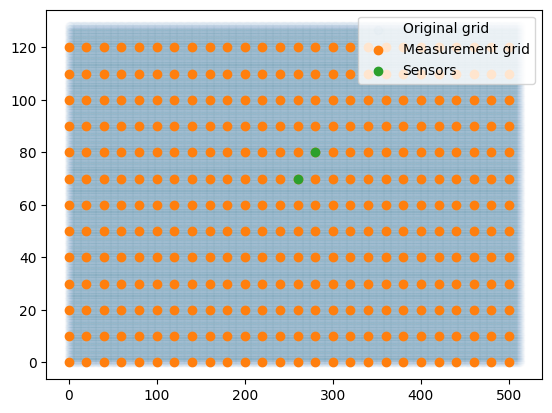

Displaying dimensions: [0 1]
(2, 513, 129)
Processing dataset 'Input' with shape (2, 513, 129)...
Processing dataset 'POD 4 modes' with shape (2, 513, 129)...
Processing dataset 'Error' with shape (2, 513, 129)...
========= POD-ESN model complete =========


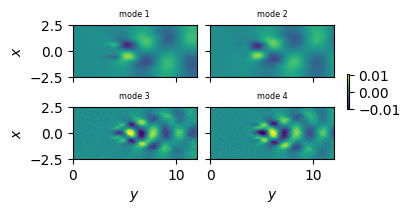

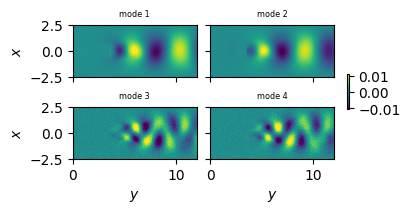

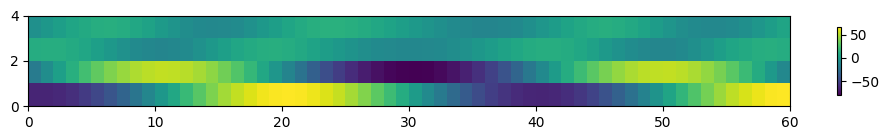

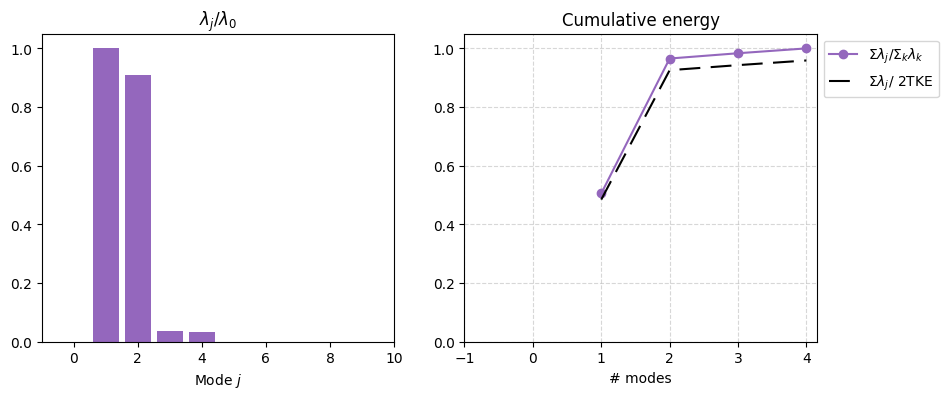

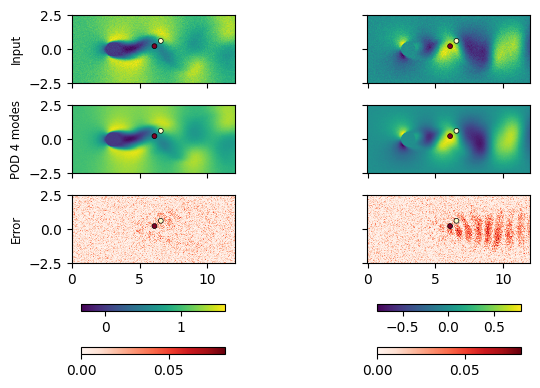

In [7]:
from romda.models.data_driven import POD_ESN


case_POD_ESN = POD_ESN(data=X_train,
                       
                    # ====== POD arguments ======== # 
                    domain=[0, 12, -2.5, 2.5],  
                    N_modes=4,  
                    skip_sensor_placement=False,
                    qr_selection=True,
                    down_sample_measurement=[20, 10],
                    
                    # ====== ESN arguments ======== # 
                    t_val=t_val,
                    t_train=t_train,
                    t_test=0.,
                    N_units=40, 
                    train_ESN=True,
                    N_wash=5,
                    noise=1E-4,
                    N_func_evals=26,
                    rho_range=[0.2, 0.9],
                    upsample=2,            
                    Nq=2, 
                  
                    # ====== Model arguments ======== # 
                    dt = dt,
                    figs_folder=simulation_dir, 
                    plot_case=True
                    )


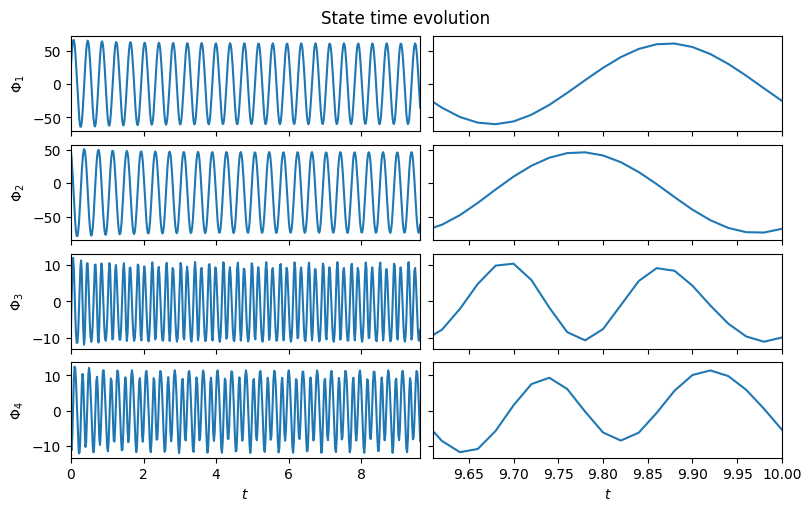

In [8]:
# Check the forecast of the POD-ESN

psi, t = case_POD_ESN.time_integrate(Nt=1000)
case_POD_ESN.update_history(psi, t)

case_POD_ESN.visualize_state_hist(max_modes=case_POD_ESN.N_modes, 
                                  t_zoom=N_train)

 
# Part II. State estimation via data assimilation

<a><img src="../../../docs/figs/DA/POD-ESN_DA.png" width=800px></a>


How many datapoints do we want to assimilate?

In [18]:
X_filter.shape

(2, 740, 513, 129)

OK: Observations initialized.


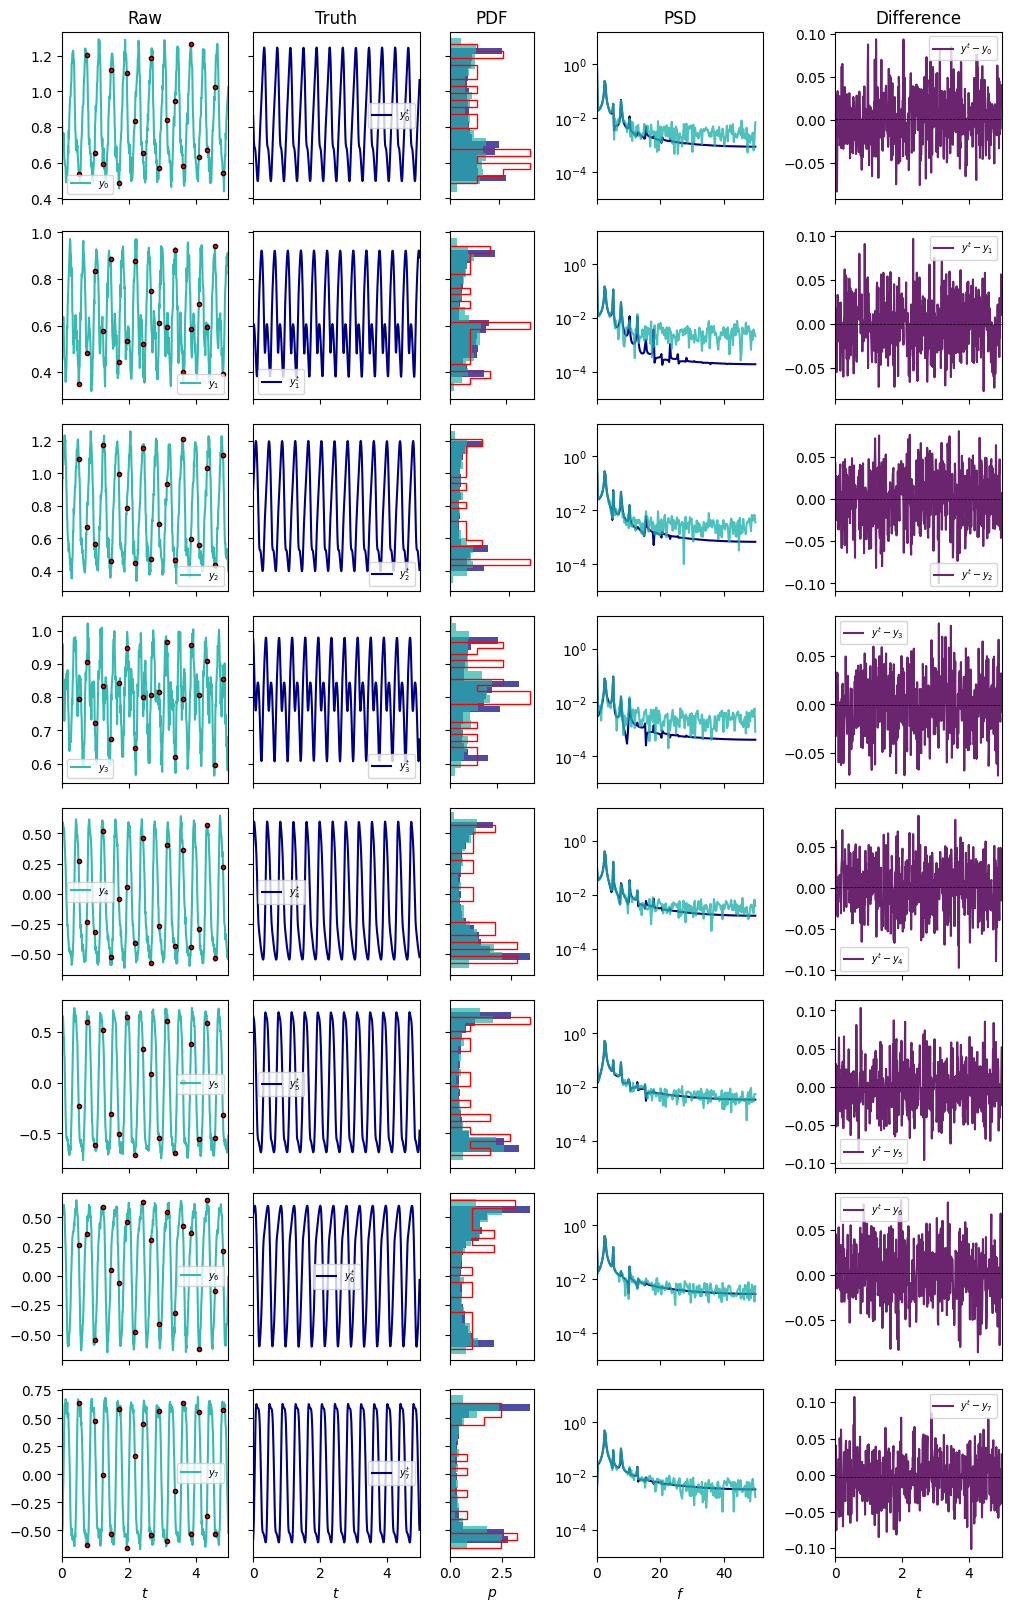

In [19]:
from romda.observations import Observations

N_test = X_filter.shape[1]

X_flat  = X_filter.transpose(1, 0, 2, 3).reshape(N_test, -1) # Nt x Ndof
X_flat_true  = X_filter_true.transpose(1, 0, 2, 3).reshape( N_test, -1) # Nt x Ndof

data_obs = X_flat[:, case_POD_ESN.sensor_locations]
data_obs_true = X_flat_true[:, case_POD_ESN.sensor_locations]

dt = case_POD_ESN.dt
t_true = np.arange(0, N_test) * dt

t_start = 0.5
t_stop = min(5., t_true[-10])

truth = Observations(
    y_raw=data_obs,          # shape (N_test, Nq)
    y_true=data_obs_true,    # shape (N_test, Nq)
    t_true=t_true,
    t_start=t_start,
    t_stop=t_stop,
    Nt_obs=0.25 // dt, #time steps between two observations
    )


Observations.plot_truth(truth, window=5, fig_width=10)

#### Initialize the ensemble 



In [20]:
from romda.estimators import EnSRKF

ensemble = EnSRKF(parent_model=case_POD_ESN,
                    m=50,
                    std_phi=1.1)

OK: Initialized my_ESN_ensemble_m50 history with shape: (1, 44, 50) and [0.]
52 44 0 (8, 52)


In [ ]:
# NOTE: the sensor-placement indexing bug has been fixed: the sensor locations
# (raw-grid indices) are now correctly mapped to the POD-basis rows when
# evaluating the model observables (see POD.grid_index_to_flat_rows).

In [21]:
import numpy as np

filter_ens = ensemble.copy()

std_obs = .01 * np.max(truth.t_obs) # observation error standard deviation
Cdd = np.eye(filter_ens.model.Nq) * std_obs**2

for d, t_d in zip(truth.y_obs, truth.t_obs):
    filter_ens.forecast_step(t_end=t_d)
    filter_ens.analysis_step(d=d, Cdd=Cdd)
    filter_ens.assimilated_data = (d, t_d)


Aa not real, returning Af
Aa not real, returning Af
Aa not real, returning Af


In [22]:

y_model = filter_ens.model.get_observables()

In [23]:
y_model.shape, filter_ens.model.hist.shape


((8, 50), (483, 44, 50))

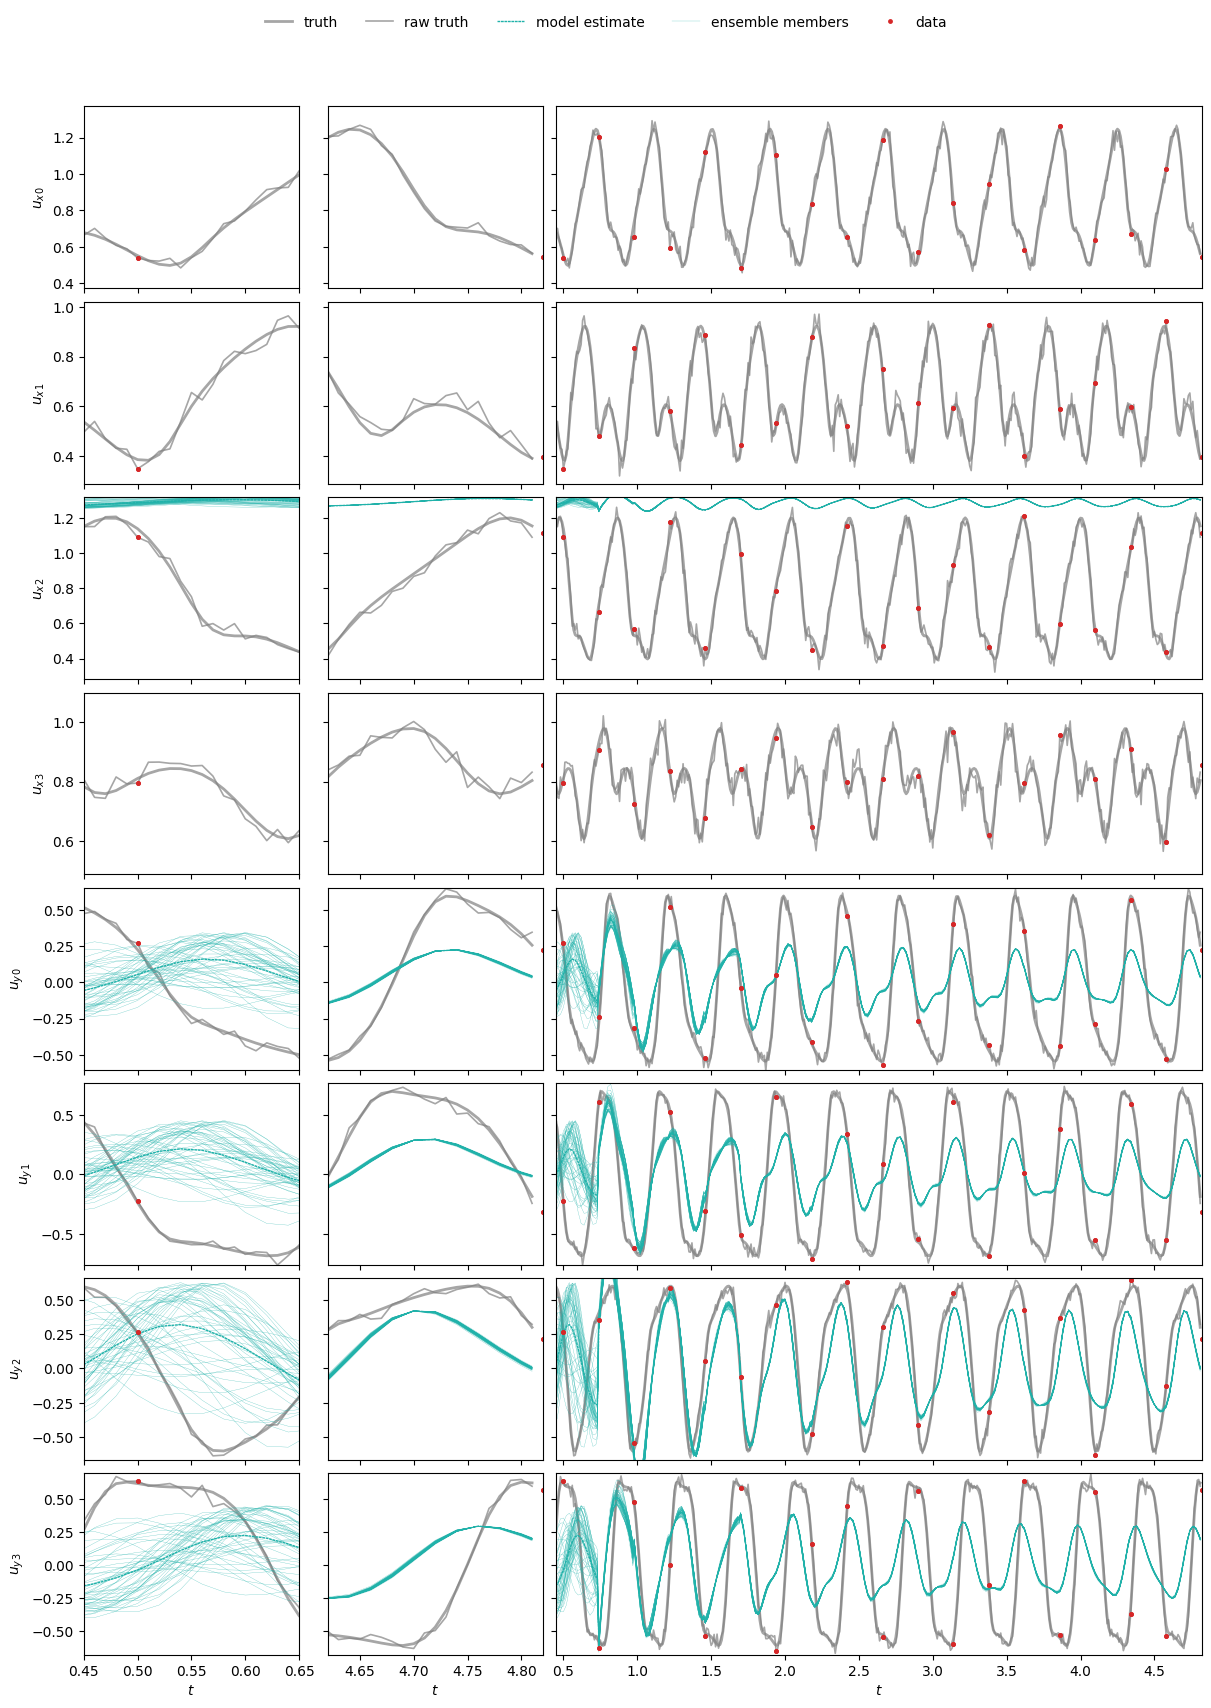

In [24]:

filter_ens.visualize_history(plot_members=True, 
                             truth=truth)


# Part II. State & Parameter estimation: online learning of Wout
Why us the SVD interesting in this scenario? Because we can use data assimialtion to modify on the fly the value of the singluar values. This is, we can perform state and parameter inference with the ESN on the fly. In machine learning jargon, this is known as *online learning*.

With this objective, we first need to create an ensemble of POD-ESN with different SVDs for each ensemble member. This is achieved by providing `Wout` as the parameter to estimate, i.e., as the `est_a` argument. The `sta_a` parameter indicates the uncewrtainty around the Wout SVDs.


## Singular value decomposition of Wout
We can decompose the trained Wout into its singular value components using the library ```scipy.linalg```. The multiplication of the three matrices are equivalent to the original Wout. 

Dimensions of matrices: (41, 4) (4,) (4, 4)


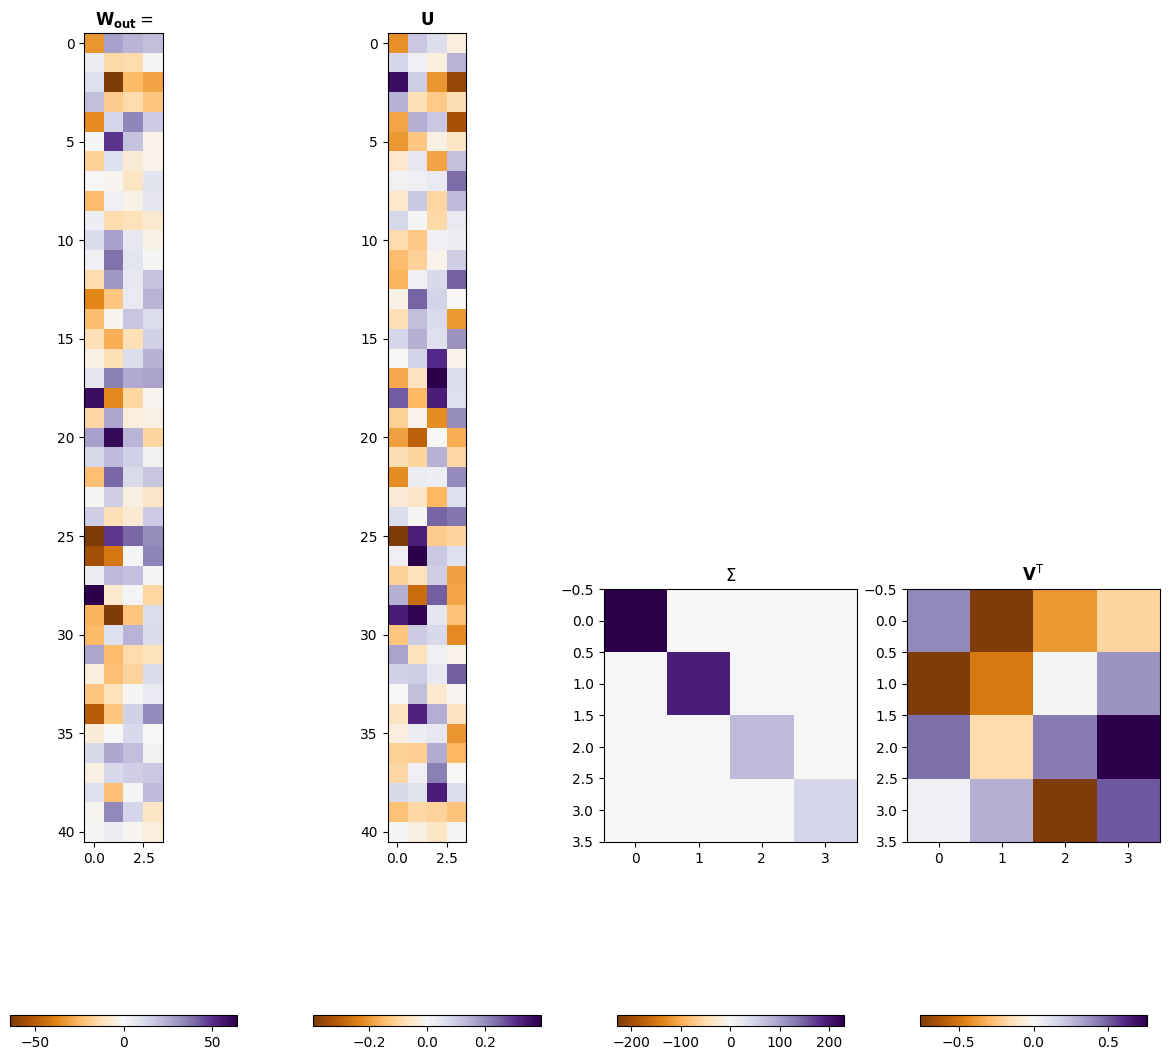

In [25]:
import scipy.linalg as sla
import matplotlib.pyplot as plt


# Compute the SVD of the output matrix
[Wout_U, Wout_eigs, Wout_Vh] = sla.svd(ensemble.model.Wout, full_matrices=False)


# #display the three matrices
fig, axs = plt.subplots(1, 4, figsize=(15, 15), width_ratios=[1, 1, 1, 1])
for W, ax, title in zip([ensemble.model.Wout, Wout_U, np.diag(Wout_eigs), Wout_Vh], axs, 
                        ['$\\mathbf{W_{out}} = $', '$\\mathbf{U}$', '$\\Sigma$', '$\\mathbf{V}^\\mathrm{T}$']):
    im = ax.imshow(W, cmap='PuOr', vmin=-np.max(W), vmax=np.max(W))
    ax.set(title=title)
    # set the same colorbar for all the matrices
    fig.colorbar(im, ax=ax, shrink=.9, orientation='horizontal')

print('Dimensions of matrices:', Wout_U.shape, Wout_eigs.shape, Wout_Vh.shape)

assert np.allclose(ensemble.model.Wout, np.dot(Wout_U, np.dot(np.diag(Wout_eigs), Wout_Vh)))


## State and parameter estimation on the POD-ESN

<a><img src="../../../docs/figs/DA/POD-ESN-SPE.png" width=800px></a>



In [26]:
# Define ensemble


ensemble_2 = EnSRKF(parent_model=case_POD_ESN,
                    m=50,
                    std_phi=.1,
                    est_alpha=['Wout'], # Estimate the Wout singular values
                    std_alpha=0.02       # Standard deviation of the noise added to the Wout singular values
                    )

! Warning: Could not set attribute Na=1 on Ensemble instance.
OK: Initialized my_ESN_ensemble_m50 history with shape: (1, 48, 50) and [0.]
56 44 4 (8, 56)


### Wout as SVD
Now the output matrix is decomposed in 3 matrices. the diagonal of the central one is the matrix of singular valuess. these we can modify in time via real-time DA.
Uncertainty in the parameters is also shown as increased uncertainty in the states

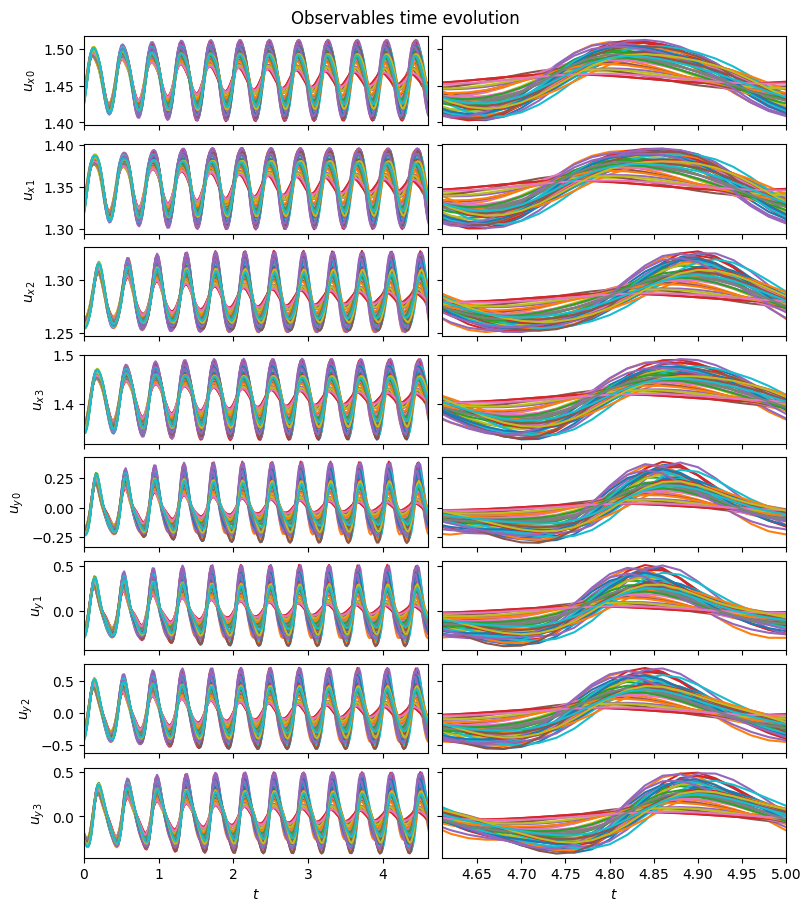

In [27]:
case = ensemble_2.model.copy()
psi, t = case.time_integrate(Nt=500)
case.update_history(psi, t)
case.visualize_observable_hist(t_zoom=N_train)

In [28]:

truth = Observations(
    y_raw=data_obs,          
    y_true=data_obs_true,    
    t_true=np.arange(0, N_test) * case_POD_ESN.dt,
    t_start=0.5,
    t_stop=10.,
    Nt_obs=0.15 // case_POD_ESN.dt, #time steps between two observations
    )


OK: Observations initialized.


Aa not real, returning Af
Aa not real, returning Af
Aa not real, returning Af
Aa not real, returning Af


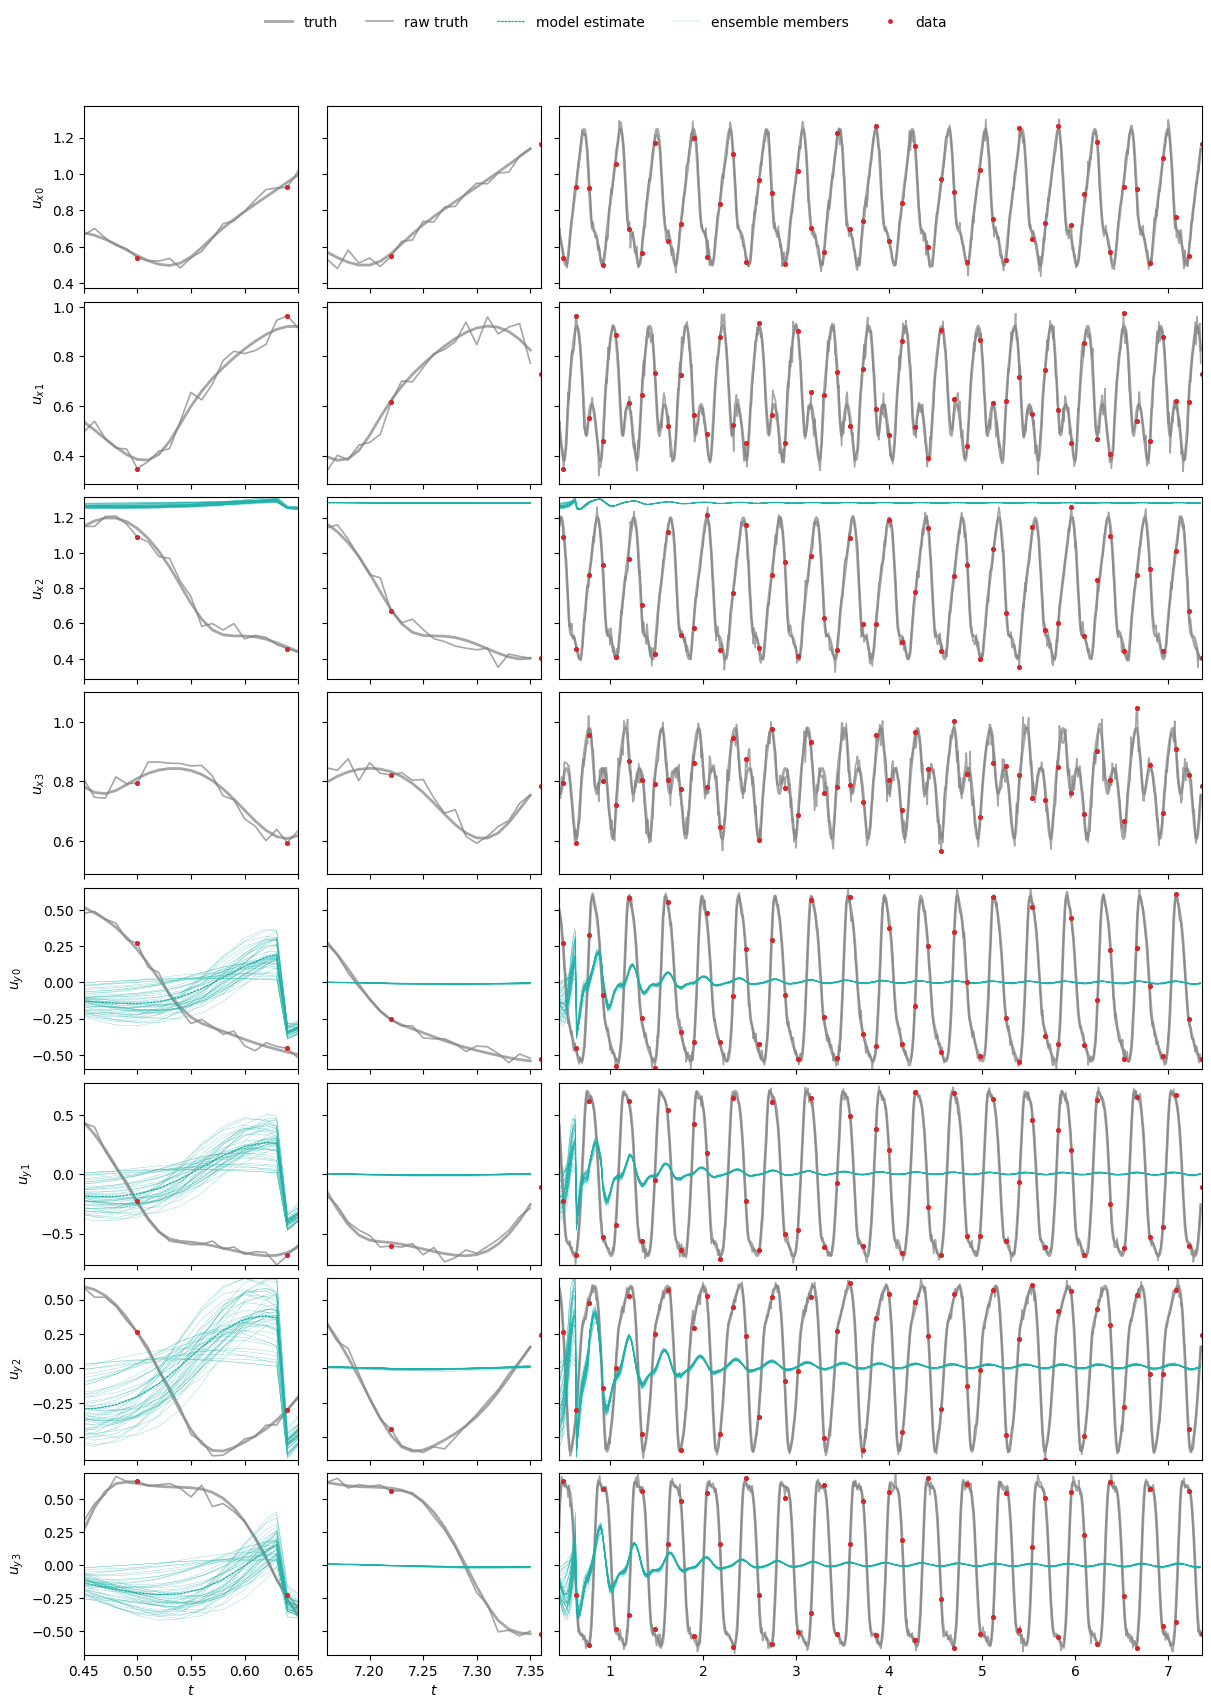

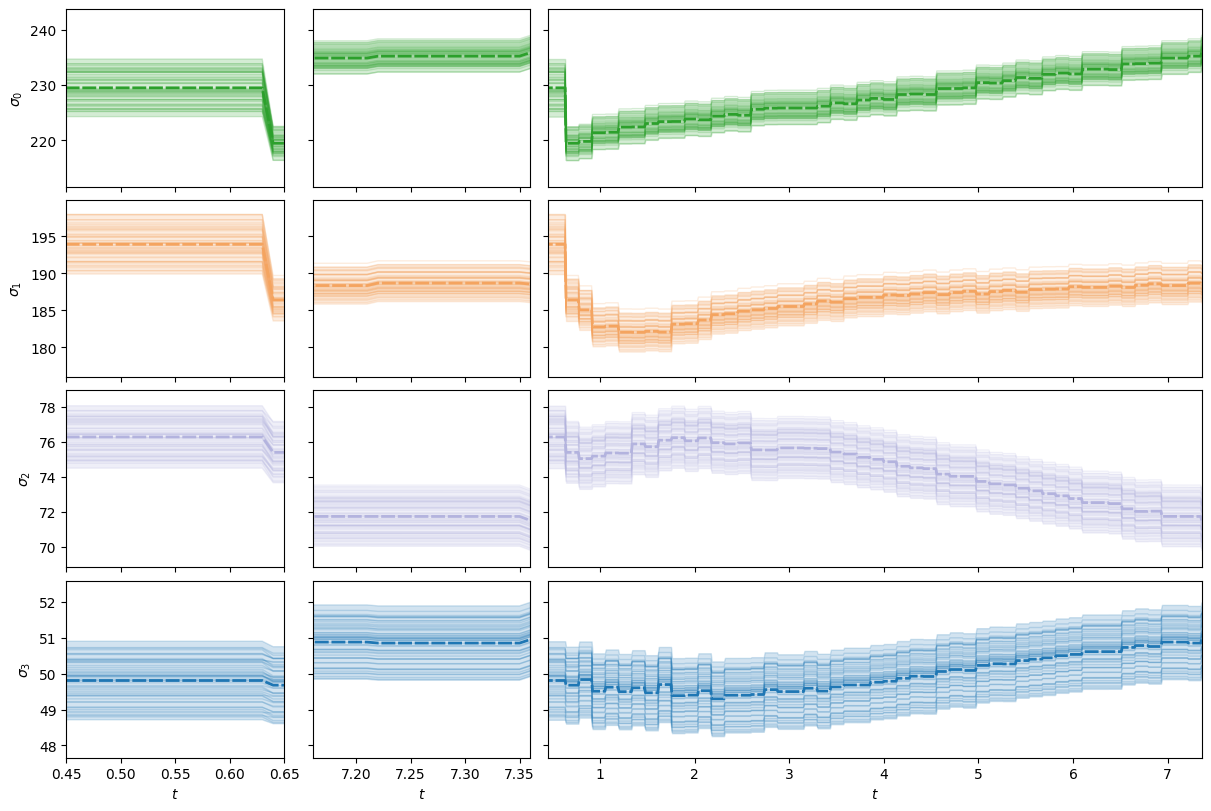

In [29]:
import numpy as np

filter_ens = ensemble_2.copy()
filter_ens.update_history(psi[-1], 0.0, reset=True)

std_obs = .01 * np.max(truth.t_obs) # observation error standard deviation
Cdd = np.eye(filter_ens.model.Nq) * std_obs**2

for d, t_d in zip(truth.y_obs, truth.t_obs):
    filter_ens.forecast_step(t_end=t_d)
    filter_ens.analysis_step(d=d, Cdd=Cdd)
    filter_ens.assimilated_data = (d, t_d)

filter_ens.visualize_history(plot_members=True, 
                             truth=truth)


In [ ]:
# Visualize the flow field reconstruction
from romda.utils import animate_flowfields

case = filter_ens.model.copy() #type: POD_ESN

time = case.hist_t
hist = case.hist[:, :case.N_modes, :]

prediction_ensemble =[]

for mi in range(filter_ens.m):
    if mi > 10:
        break
    prediction_mi = case.decode(Z=hist[..., mi].T)
    prediction_ensemble.append(prediction_mi)

prediction_ensemble = np.array(prediction_ensemble)
prediction_mean = np.mean(prediction_ensemble, axis=0)
prediction_std = np.std(prediction_ensemble, axis=0) 



In [ ]:

test_data = X_filter[:, :len(time)].transpose(1, 0, 2, 3).reshape(len(time), -1) # Nt x Ndof
test_data_true = X_filter_true[:, :len(time)].transpose(1, 0, 2, 3).reshape(len(time), -1) # Nt x Ndof


In [ ]:
prediction_mean.shape, prediction_std.shape, test_data.shape, test_data_true.shape

((132354, 737), (132354, 737), (737, 132354), (737, 132354))

In [ ]:

# Compute Error metrics
RMS_noisy = np.array([POD_ESN.compute_RMS(test_data[ti], prediction_mean[:,ti]) 
                      for ti in range(prediction_mean.shape[-1])])


In [ ]:
Nu, Nx, Ny = X_filter.shape[0], X_filter.shape[2], X_filter.shape[3]

def reshape_U(_U):
    return _U.reshape(-1, Nu, Nx, Ny).transpose(1, 2, 3, 0) # reshape to (Nt, 1) 

    

In [ ]:
reshape_U(test_data).shape, reshape_U(test_data_true).shape, reshape_U(prediction_mean).shape, reshape_U(prediction_std).shape

((2, 513, 129, 737),
 (2, 513, 129, 737),
 (2, 513, 129, 737),
 (2, 513, 129, 737))

In [ ]:
# sensors = case.sensor_locations[case.sensor_locations < test_data.shape[1] * test_data.shape[2]]
# x_col = sensors // test_data.shape[2]
# y_row = sensors % test_data.shape[2]



U_datasets = {'Truth': reshape_U(test_data)[0], 
              'POD_ESN mean': reshape_U(prediction_mean)[0], 
              'POD_ESN std': reshape_U(prediction_std)[0], 
              'RMS Error': reshape_U(RMS_noisy)[0]
              }

# compute the observation indices in the downsampled time history
anim = animate_flowfields(U_datasets, 
                          time=time, 
                          n_frames=50, figsize=(8, 6), step=5,
                        #   assimilated_data={'t_obs': truth.t_obs,   # observation times
                        #                     'xy': np.column_stack((x_col, y_row))  # sensor locations
                        #                     }
                          )

In [ ]:
from IPython.display import HTML
HTML(anim.to_jshtml())